# Наличие товара на филиалах по дням

Задача: для одной товарной категории построить полную историю **остатков каждого филиала по каждому дню** -
хотя учётная система (1С) хранит только текущий остаток и журнал движений (поступления, продажи, перемещения,
списания). Ежедневный снимок восстанавливается расчётом: берём текущий остаток и «откатываем» его назад по
дням, вычитая движения. Это намного легче для СУБД, чем запрашивать историю остатков напрямую.

Итог - таблица «дата × товар × филиал» с восстановленным остатком (в штуках и в рублях по приоритетной цене)
и продажами за день. На ней строится анализ наличия: где и когда товара не было на полке и сколько продаж
из-за этого потеряно.

**Про данные.** Расчёт идёт на синтетических данных из общей базы [`../synthetic_data`](../synthetic_data):
таблицы повторяют структуру выгрузок 1С (справочники, счёт 41, счёт 90, текущий остаток), а движения
получены симуляцией сети магазинов электроники - с заказами у РРЦ, сроками доставки, перебоями у поставщика и
выходом новой линейки iPhone в конце сентября 2025. Названия моделей реальные, цены и объёмы условные.
Симуляция хранит и «истинную» историю остатков - на ней в конце проверяется, что восстановление точное.

## Импорт библиотек

In [1]:
import os
import gc
import warnings
import itertools
from datetime import timedelta

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm import tqdm

pd.options.display.max_columns = 100
sns.set_theme(style='whitegrid', font_scale=0.95)
plt.rcParams['figure.dpi'] = 110
warnings.filterwarnings('ignore', category=FutureWarning)

## Настройка параметров

In [2]:
DB_PATH = os.environ.get('SYNTH_DB', '../synthetic_data/synthetic_projects.duckdb')

# Категория, для которой строится расчёт (4-й уровень иерархии категорий)
CATEGORY = 'Apple Смартфоны'

# Период: последние PERIOD_DAYS дней до даты текущего остатка
PERIOD_DAYS = 92

# Виды филиалов, которые учитываются в расчёте (магазины, дисконт-центры, РРЦ - не склады и офисы)
RETAIL_BRANCH_TYPES = ['Магазин', 'Дисконт центр', 'РРЦ']

## Функции

In [3]:
con = duckdb.connect(DB_PATH)


def execute_to_df(sql: str, params=None) -> pd.DataFrame:
    """SQL к базе с синтетикой. В рабочей версии здесь был запрос к базе 1С через внутренний пакет доступа."""
    return con.execute(sql, params or []).df()

In [4]:
def reduce_mem_usage(df: pd.DataFrame, int_cast=True, obj_to_category=False, subset=None, verbose=False) -> pd.DataFrame:
    """
    Понижает типы данных датафрейма до минимально достаточных (int8/16/32, float16/32) - на таблицах вида
    Дата x Товар x Филиал (миллионы строк) это ощутимо снижает потребление памяти.
    """
    start_mem = df.memory_usage().sum() / 1024 ** 2
    gc.collect()

    cols = subset if subset is not None else df.columns.tolist()
    for col in tqdm(cols, disable=not verbose):
        col_type = df[col].dtype
        if col_type != object and col_type.name != 'category' and 'datetime' not in col_type.name:
            c_min, c_max = df[col].min(), df[col].max()
            treat_as_int = str(col_type)[:3] == 'int' or (int_cast and isinstance(df[col], int))
            if treat_as_int:
                for np_type in (np.int8, np.uint8, np.int16, np.uint16, np.int32, np.uint32, np.int64, np.uint64):
                    info = np.iinfo(np_type)
                    if c_min > info.min and c_max < info.max:
                        df[col] = df[col].astype(np_type)
                        break
            else:
                for np_type in (np.float32,):
                    info = np.finfo(np_type)
                    if c_min > info.min and c_max < info.max:
                        df[col] = df[col].astype(np_type)
                        break
                else:
                    df[col] = df[col].astype(np.float64)
        elif 'datetime' not in col_type.name and obj_to_category:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024 ** 2
    print(f'{len(df):,} строк, память {start_mem:.2f} -> {end_mem:.2f} МБ')
    return df

## Алгоритм выполнения

### Календарь и справочник категорий

In [5]:
END_DATE = pd.Timestamp(execute_to_df("SELECT MAX(ДатаОстатка) AS d FROM electronics.stock_now").d[0])
first_move = pd.Timestamp(execute_to_df("SELECT MIN(Дата) AS d FROM electronics.schet_41").d[0])
START_DATE = max(END_DATE - timedelta(days=PERIOD_DAYS - 1), first_move)
print(f'Период: {START_DATE:%d.%m.%Y} - {END_DATE:%d.%m.%Y}')

calendar_df = pd.DataFrame({'datetime': pd.date_range(start=START_DATE, end=END_DATE, freq='D')})
calendar_df['Дата'] = calendar_df['datetime'].dt.date.astype(str)
calendar_df = calendar_df.reset_index().rename(columns={'index': 'i_date'})
calendar_df = reduce_mem_usage(calendar_df)

Период: 01.08.2025 - 31.10.2025
92 строк, память 0.00 -> 0.00 МБ


Справочник товаров выбранной категории с ассортиментным статусом (готовый статус из 1С: новинка, основной
ассортимент, выводимый товар - используется как атрибут для срезов).

In [6]:
df_category = execute_to_df("""
    SELECT ТоварСсылка, Код, Товар, Категория1, Категория2, Категория3, Категория4, Ассортиментный_Статус
    FROM electronics.products
    WHERE Категория4 = ?
    ORDER BY Код
""", [CATEGORY])
df_category = df_category.reset_index().rename(columns={'index': 'i_product'})
df_category = reduce_mem_usage(df_category)
df_category[['Код', 'Товар', 'Ассортиментный_Статус']].head()

60 строк, память 0.00 -> 0.00 МБ


,Код,Товар,Ассортиментный_Статус
0,5100000,Смартфон Apple iPhone 15 128GB Black,Выводимый
1,5100017,Смартфон Apple iPhone 15 128GB Blue,Выводимый
2,5100034,Смартфон Apple iPhone 15 128GB Pink,Выводимый
3,5100051,Смартфон Apple iPhone 15 256GB Black,Выводимый
4,5100068,Смартфон Apple iPhone 15 256GB Blue,Выводимый


### Приоритетная цена товара

Из нескольких видов цен в 1С (ФЦ ОРП, РФЦ обычная, РФЦ от себестоимости) берётся первая заполненная по
приоритету - дальше она нужна только для перевода остатков и продаж из штук в рубли.

In [7]:
df_price = execute_to_df("""
    SELECT pr.Номенклатура AS ТоварСсылка,
           COALESCE(pr.ФЦ_ОРП, pr.РФЦ_обычная, pr.РФЦ_от_себестоимости, 0) AS ПриоритетнаяЦена
    FROM electronics.prices pr
    JOIN electronics.products p ON p.ТоварСсылка = pr.Номенклатура
    WHERE p.Категория4 = ?
""", [CATEGORY])
df_price = df_price.merge(df_category[['ТоварСсылка', 'i_product']], on='ТоварСсылка').drop(columns='ТоварСсылка')
df_price['ПриоритетнаяЦена'] = df_price['ПриоритетнаяЦена'].astype(int)
df_price = reduce_mem_usage(df_price)

60 строк, память 0.00 -> 0.00 МБ


### Справочник филиалов

In [8]:
df_branches = execute_to_df("SELECT ФилиалСсылка, Филиал, Вид_филиала, ПриписанК_Складу FROM electronics.branches")
df_branches = df_branches.reset_index().rename(columns={'index': 'i_branch'})
df_branches = reduce_mem_usage(df_branches)
df_branches.Вид_филиала.value_counts().to_frame('филиалов')

41 строк, память 0.00 -> 0.00 МБ


,филиалов
Вид_филиала,
Магазин,32
Дисконт центр,4
РРЦ,3
Склад,1
Офис,1


### Движения товара (счёт 41) и продажи (счёт 90)

Счёт 41 и счёт 90 - стандартные бухгалтерские регистры 1С: 41 - движение товара (поступления, продажи,
перемещения, списания в штуках и сумме), 90 - реализация (фактические продажи). Оба берутся с начала периода
и агрегируются по дню, товару и филиалу.

In [9]:
df_schet_41 = execute_to_df("""
    SELECT m.Дата, m.ВидДвижения, m.Номенклатура AS ТоварСсылка, m.Филиал AS ФилиалСсылка,
           SUM(m.Количество) AS Количество, SUM(m.Сумма) AS Сумма
    FROM electronics.schet_41 m
    JOIN electronics.products p ON p.ТоварСсылка = m.Номенклатура
    WHERE p.Категория4 = ? AND m.Дата >= ?
    GROUP BY 1, 2, 3, 4
""", [CATEGORY, START_DATE])
df_schet_41['Дата'] = df_schet_41['Дата'].dt.date.astype(str)

df_schet_41 = df_schet_41.merge(df_category[['ТоварСсылка', 'i_product']], on='ТоварСсылка')
df_schet_41 = df_schet_41.merge(df_branches[['ФилиалСсылка', 'i_branch']], on='ФилиалСсылка')
df_schet_41 = df_schet_41.merge(calendar_df[['Дата', 'i_date']], on='Дата')
df_schet_41 = df_schet_41.drop(columns=['ТоварСсылка', 'ФилиалСсылка', 'Дата'])
df_schet_41[['ВидДвижения', 'Количество', 'Сумма']] = df_schet_41[['ВидДвижения', 'Количество', 'Сумма']].astype(int)
df_schet_41 = reduce_mem_usage(df_schet_41)

38,409 строк, память 0.55 -> 0.37 МБ


In [10]:
df_schet_90 = execute_to_df("""
    SELECT s.Дата, s.Номенклатура AS ТоварСсылка, s.Филиал AS ФилиалСсылка,
           SUM(s.Количество) AS Количество, SUM(s.СуммаСебес) AS СуммаСебес
    FROM electronics.schet_90 s
    JOIN electronics.products p ON p.ТоварСсылка = s.Номенклатура
    WHERE p.Категория4 = ? AND s.Дата >= ?
    GROUP BY 1, 2, 3
""", [CATEGORY, START_DATE])
df_schet_90['Дата'] = df_schet_90['Дата'].dt.date.astype(str)

df_schet_90 = df_schet_90.merge(df_category[['ТоварСсылка', 'i_product']], on='ТоварСсылка')
df_schet_90 = df_schet_90.merge(df_branches[['ФилиалСсылка', 'i_branch']], on='ФилиалСсылка')
df_schet_90 = df_schet_90.merge(calendar_df[['Дата', 'i_date']], on='Дата')
df_schet_90 = df_schet_90.drop(columns=['ТоварСсылка', 'ФилиалСсылка', 'Дата'])
df_schet_90[['СуммаСебес', 'Количество']] = df_schet_90[['СуммаСебес', 'Количество']].astype(int)
df_schet_90 = reduce_mem_usage(df_schet_90)

22,743 строк, память 0.24 -> 0.17 МБ


### Текущий остаток

In [11]:
df_stock_now = execute_to_df("""
    SELECT s.ДатаОстатка AS Дата, s.Номенклатура AS ТоварСсылка, s.Филиал AS ФилиалСсылка,
           s.Остаток, s.Резерв, s.МягкийРезерв, s.Транзит, s.Путь
    FROM electronics.stock_now s
    JOIN electronics.products p ON p.ТоварСсылка = s.Номенклатура
    WHERE p.Категория4 = ?
""", [CATEGORY])
df_stock_now['Дата'] = df_stock_now['Дата'].dt.date.astype(str)

df_stock_now = df_stock_now.merge(df_category[['ТоварСсылка', 'i_product']], on='ТоварСсылка')
df_stock_now = df_stock_now.merge(df_branches[['ФилиалСсылка', 'i_branch']], on='ФилиалСсылка')
df_stock_now = df_stock_now.merge(calendar_df[['Дата', 'i_date']], on='Дата')
df_stock_now = df_stock_now.drop(columns=['ТоварСсылка', 'ФилиалСсылка', 'Дата'])
df_stock_now[['Остаток', 'Резерв', 'МягкийРезерв', 'Транзит', 'Путь']] = \
    df_stock_now[['Остаток', 'Резерв', 'МягкийРезерв', 'Транзит', 'Путь']].astype(int)
df_stock_now = reduce_mem_usage(df_stock_now)

2,266 строк, память 0.05 -> 0.02 МБ


### Восстановление дневных остатков

Знак движения зависит от его вида (приход увеличивает остаток, расход уменьшает) - сворачиваем его в
множитель, дальше движения агрегируются по дню, товару и филиалу.

In [12]:
df_schet_41['Множитель'] = df_schet_41['ВидДвижения'].apply(lambda x: -1 if x == 1 else 1)
df_schet_41['Движения'] = df_schet_41['Количество'] * df_schet_41['Множитель']
df_schet_41['Сумма_мод'] = df_schet_41['Сумма'] * df_schet_41['Множитель']

schet_41_by_day = df_schet_41[['i_date', 'i_product', 'i_branch', 'Движения', 'Сумма_мод']]\
    .groupby(by=['i_date', 'i_product', 'i_branch']).agg('sum').reset_index()

Полная матрица «дата × филиал × товар» (декартово произведение) - нужна, чтобы у каждого товара на каждом
филиале была строка на каждый день, даже если в этот день не было ни движений, ни продаж: иначе восстановление
«назад по дням» дало бы разрывы.

In [13]:
retail_branches = df_branches[df_branches['Вид_филиала'].isin(RETAIL_BRANCH_TYPES)]
products_with_movements = list(set(schet_41_by_day['i_product']))

matrix = pd.DataFrame(
    list(itertools.product(calendar_df['i_date'], retail_branches['i_branch'], pd.Series(products_with_movements))),
    columns=['i_date', 'i_branch', 'i_product'],
)
matrix = reduce_mem_usage(matrix)

215,280 строк, память 4.93 -> 0.62 МБ


**Восстановление остатка по дням.** Текущий остаток на последний день периода известен точно. Двигаясь назад
по датам, вычитаем чистое движение за день и получаем остаток на начало каждого более раннего дня. Реализовано
через `cumsum()` в обратном порядке дат: накопительная сумма разницы «остаток - движение».

Отличие от первоначальной версии: раньше здесь отбрасывались все строки с нулевым остатком - но это как раз
дни, когда товара не было на полке, ради которых расчёт и делается. Теперь отбрасываются только пары
«товар-филиал», у которых остатка не было за весь период.

In [14]:
merged = matrix.merge(df_stock_now[['i_date', 'i_branch', 'i_product', 'Остаток']], on=['i_date', 'i_branch', 'i_product'], how='left')
merged = merged.merge(schet_41_by_day[['i_date', 'i_branch', 'i_product', 'Движения']], on=['i_date', 'i_branch', 'i_product'], how='left')
merged = merged.merge(df_schet_90[['i_date', 'i_branch', 'i_product', 'Количество']], on=['i_date', 'i_branch', 'i_product'], how='left')
merged = merged.fillna(0)
merged['ПоДням'] = merged['Остаток'] - merged['Движения']

merged = merged.sort_values(by=['i_product', 'i_branch', 'i_date'], ascending=False)
merged['Остатки_шт'] = merged.groupby(['i_product', 'i_branch'])['ПоДням'].cumsum()

# пары «товар-филиал», где товара не было ни в один день периода, - не ассортимент филиала, убираем
ever_stocked = merged.groupby(['i_product', 'i_branch'])['Остатки_шт'].transform('max') > 0
merged = merged[ever_stocked].sort_values(['i_product', 'i_branch', 'i_date'])

### Сборка итоговой таблицы

In [15]:
merged = merged.rename(columns={'Количество': 'Продажи_шт'})

merged = merged.merge(df_category[['i_product', 'Код', 'Товар', 'Ассортиментный_Статус', 'ТоварСсылка']], on='i_product', how='left')
merged = merged.merge(df_branches[['i_branch', 'Филиал', 'Вид_филиала', 'ПриписанК_Складу', 'ФилиалСсылка']], on='i_branch', how='left')
merged = merged.merge(calendar_df[['i_date', 'Дата', 'datetime']], on='i_date', how='left')
merged = merged.merge(df_price[['i_product', 'ПриоритетнаяЦена']], on='i_product', how='left')
merged = merged.drop(columns=['i_date', 'i_branch', 'i_product', 'Остаток', 'ПоДням'])

merged['Остатки_руб'] = merged['Остатки_шт'] * merged['ПриоритетнаяЦена']
merged['Продажи_руб'] = merged['Продажи_шт'] * merged['ПриоритетнаяЦена']
merged[['Дата', 'Товар', 'Филиал', 'Остатки_шт', 'Продажи_шт', 'Остатки_руб', 'Продажи_руб']].head()

,Дата,Товар,Филиал,Остатки_шт,Продажи_шт,Остатки_руб,Продажи_руб
0,2025-08-01,Смартфон Apple iPhone 15 128GB Black,РРЦ Москва,14.0,0.0,868000.0,0.0
1,2025-08-02,Смартфон Apple iPhone 15 128GB Black,РРЦ Москва,14.0,1.0,868000.0,62000.0
2,2025-08-03,Смартфон Apple iPhone 15 128GB Black,РРЦ Москва,13.0,1.0,806000.0,62000.0
3,2025-08-04,Смартфон Apple iPhone 15 128GB Black,РРЦ Москва,12.0,1.0,744000.0,62000.0
4,2025-08-05,Смартфон Apple iPhone 15 128GB Black,РРЦ Москва,11.0,1.0,682000.0,62000.0


## Проверка: восстановленный остаток против истинного

На реальных данных такой проверки нет - есть только отдельные сверки с инвентаризациями. На синтетике
симуляция сохранила истинный остаток на начало каждого дня, и можно сравнить каждую строку.

In [16]:
truth = execute_to_df("SELECT Дата, Филиал AS ФилиалСсылка, Номенклатура AS ТоварСсылка, ОстатокНаНачалоДня, СпросИстинный "
                      "FROM electronics.stock_daily_true WHERE Дата >= ?", [START_DATE])
truth['Дата'] = truth['Дата'].dt.date.astype(str)
check = merged.merge(truth, on=['Дата', 'ФилиалСсылка', 'ТоварСсылка'], how='left').fillna({'ОстатокНаНачалоДня': 0, 'СпросИстинный': 0})
diff = check['Остатки_шт'] - check['ОстатокНаНачалоДня']
print(f'Строк «день × товар × филиал»: {len(check):,}')
print(f'Совпадает с истинным остатком: {(diff == 0).mean():.2%}, максимальное расхождение: {diff.abs().max():.0f} шт.')

Строк «день × товар × филиал»: 215,280
Совпадает с истинным остатком: 100.00%, максимальное расхождение: 0 шт.


## Анализ наличия

**День дефицита** - на начало дня товара на филиале нет и за день он не продавался (если поставка пришла днём и
товар продали, это не дефицит). Считается только по магазинам и дисконт-центрам и только по дням, когда товар
вообще был в продаже в сети (новинки - после выхода).

In [17]:
stores = merged[merged['Вид_филиала'].isin(['Магазин', 'Дисконт центр'])].copy()
on_sale = stores.groupby(['Товар', 'datetime'])['Продажи_шт'].transform('sum') > 0     # товар продаётся в сети в этот день
launched = stores.groupby('Товар')['datetime'].transform(lambda d: d.where(on_sale.loc[d.index]).min())
stores = stores[stores['datetime'] >= launched]
stores['Дефицит'] = (stores['Остатки_шт'] <= 0) & (stores['Продажи_шт'] == 0)

print(f'Доля «товаро-дней» в наличии по сети: {1 - stores["Дефицит"].mean():.1%}')

Доля «товаро-дней» в наличии по сети: 90.5%


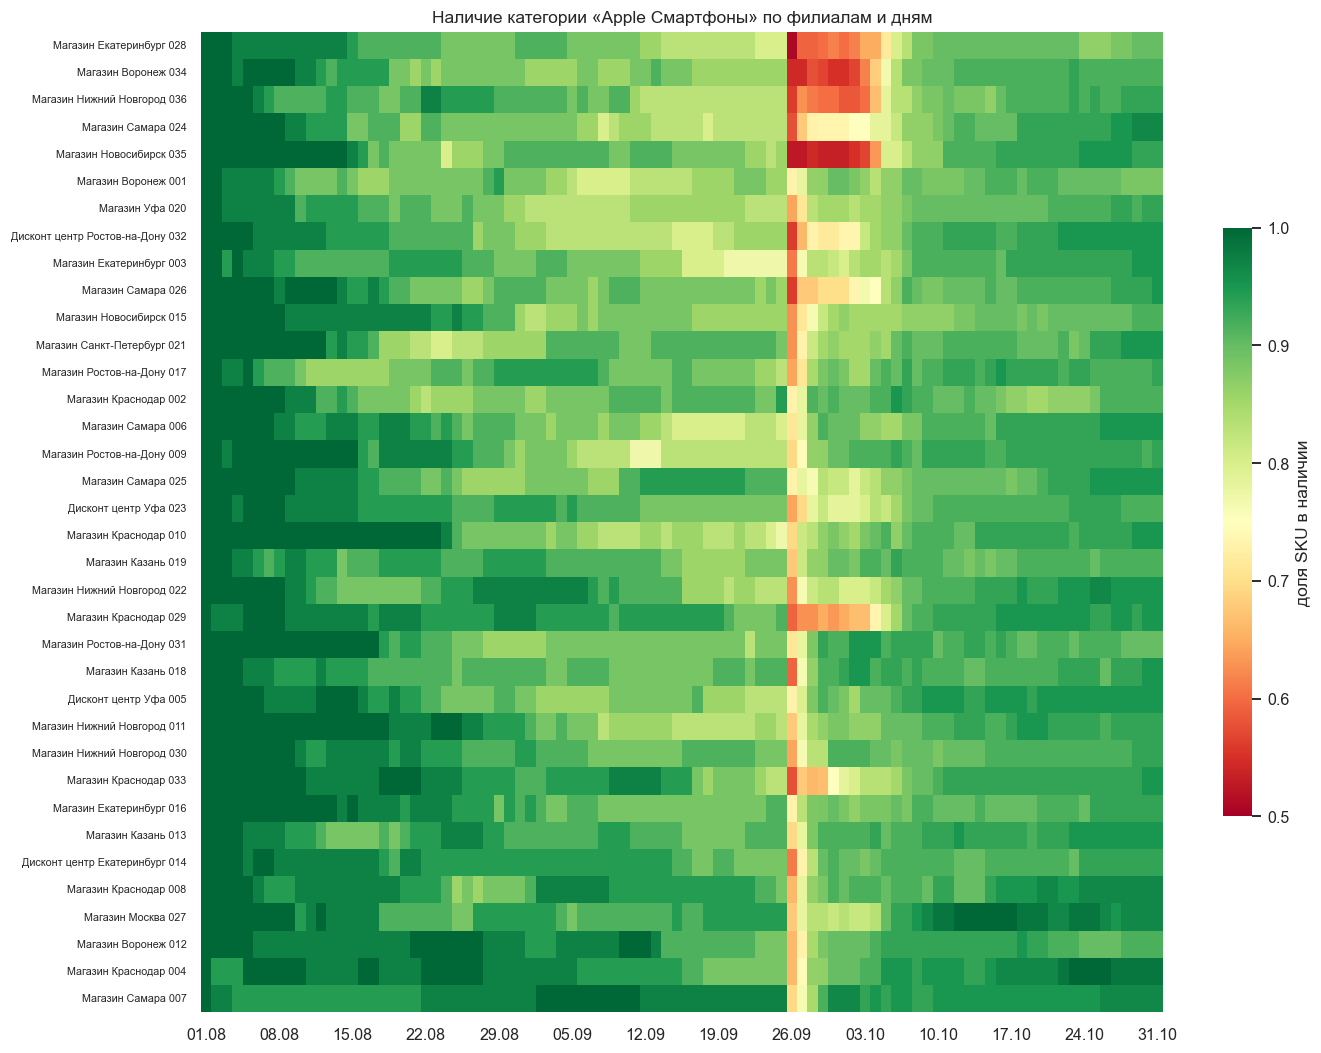

In [18]:
avail = 1 - stores.pivot_table(index='Филиал', columns='datetime', values='Дефицит', aggfunc='mean')
avail = avail.loc[avail.mean(axis=1).sort_values().index]
fig, ax = plt.subplots(figsize=(13, 0.22 * len(avail) + 1.8))
sns.heatmap(avail, cmap='RdYlGn', vmin=0.5, vmax=1, cbar_kws={'label': 'доля SKU в наличии', 'shrink': .6}, ax=ax)
ticks = np.arange(0, avail.shape[1], 7)
ax.set_xticks(ticks + .5); ax.set_xticklabels([avail.columns[i].strftime('%d.%m') for i in ticks], rotation=0)
ax.set(title=f'Наличие категории «{CATEGORY}» по филиалам и дням', xlabel='', ylabel='')
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout(); plt.show()

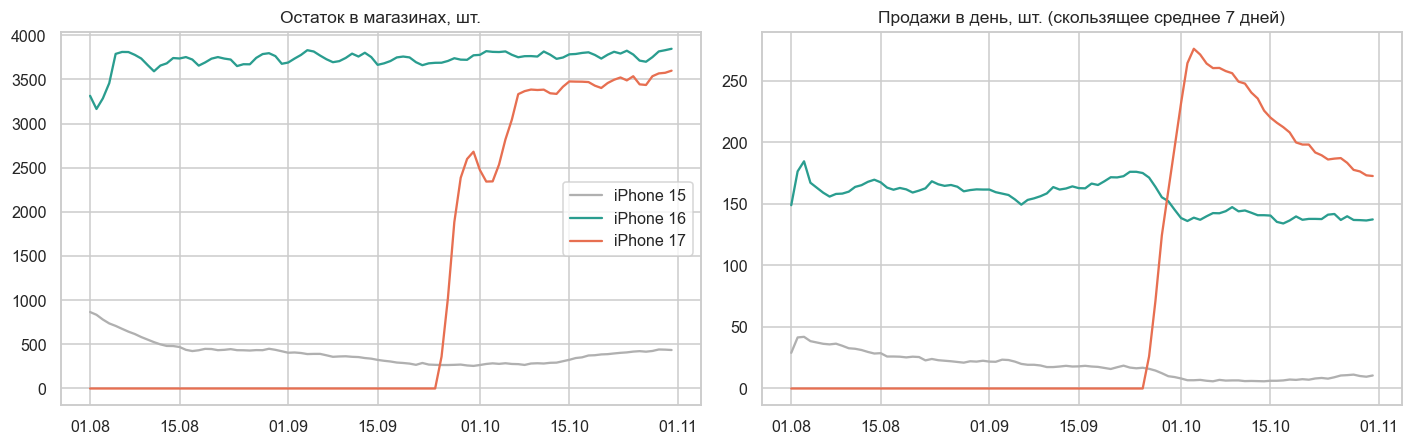

In [19]:
merged['Линейка'] = merged['Товар'].str.extract(r'(iPhone \S+)')[0].replace({'iPhone Air': 'iPhone 17', 'iPhone 16e': 'iPhone 16'})
net = merged[merged['Вид_филиала'].isin(['Магазин', 'Дисконт центр'])]\
    .groupby(['datetime', 'Линейка'])[['Остатки_шт', 'Продажи_шт']].sum().reset_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharex=True)
palette = {'iPhone 15': '#b0b0b0', 'iPhone 16': '#2a9d8f', 'iPhone 17': '#e76f51'}
for ax, col, title in [(axes[0], 'Остатки_шт', 'Остаток в магазинах, шт.'), (axes[1], 'Продажи_шт', 'Продажи в день, шт. (скользящее среднее 7 дней)')]:
    for line, g in net.groupby('Линейка'):
        y = g.set_index('datetime')[col]
        ax.plot(y.index, y.rolling(7, min_periods=1).mean() if col == 'Продажи_шт' else y, label=line, color=palette.get(line))
    ax.set_title(title); ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
axes[0].legend()
plt.tight_layout(); plt.show()

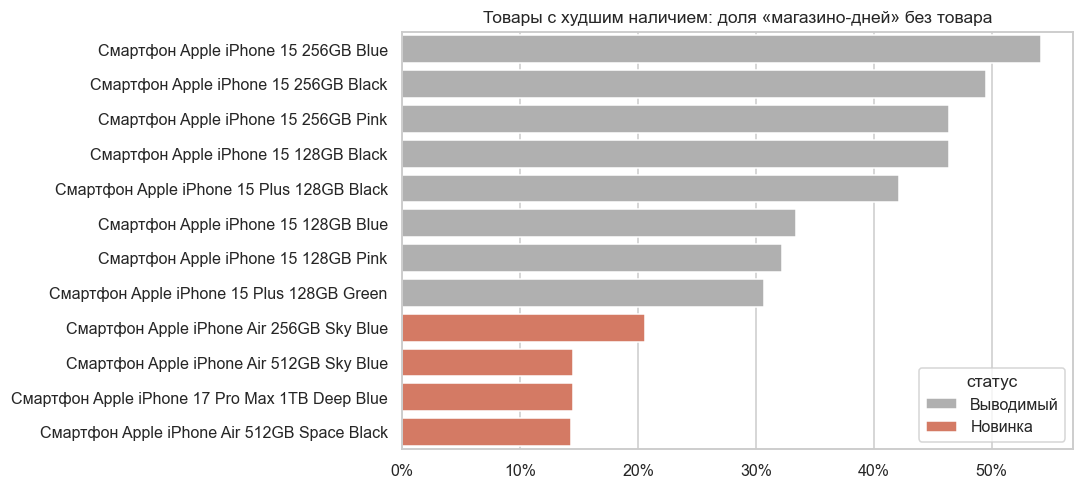

In [20]:
by_sku = stores.groupby(['Товар', 'Ассортиментный_Статус'])['Дефицит'].mean().rename('доля дней дефицита').reset_index()
worst = by_sku.sort_values('доля дней дефицита', ascending=False).head(12)
plt.figure(figsize=(10, 4.6))
sns.barplot(data=worst, y='Товар', x='доля дней дефицита', hue='Ассортиментный_Статус', dodge=False,
            palette={'Новинка': '#e76f51', 'Основной': '#2a9d8f', 'Выводимый': '#b0b0b0'})
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(1))
plt.title('Товары с худшим наличием: доля «магазино-дней» без товара'); plt.xlabel(''); plt.ylabel('')
plt.legend(title='статус', loc='lower right'); plt.tight_layout(); plt.show()

### Упущенные продажи

Оценка: для каждой пары «товар-филиал» ожидаемые продажи в день - это средние продажи в дни, когда товар был
в наличии. Умножаем на число дней дефицита и на цену. Метод простой (не учитывает сезонность и то, что часть
покупателей возьмёт соседнюю модель), но уже отделяет «не было спроса» от «не было товара».

На синтетике оценку можно сверить с истинным неудовлетворённым спросом из симуляции.

In [21]:
g = stores.groupby(['Товар', 'Филиал'])
stores['ожидаемые_продажи'] = g['Продажи_шт'].transform(lambda s: s[stores.loc[s.index, 'Дефицит'] == False].mean()).fillna(0)
stores['упущено_шт'] = np.where(stores['Дефицит'], stores['ожидаемые_продажи'], 0)
stores['упущено_руб'] = stores['упущено_шт'] * stores['ПриоритетнаяЦена']

stores = stores.merge(check[['Дата', 'ФилиалСсылка', 'ТоварСсылка', 'СпросИстинный']], on=['Дата', 'ФилиалСсылка', 'ТоварСсылка'], how='left')
stores['упущено_истинно_руб'] = (stores['СпросИстинный'] - stores['Продажи_шт']).clip(lower=0) * stores['ПриоритетнаяЦена']

total_sales = stores['Продажи_руб'].sum()
est, true = stores['упущено_руб'].sum(), stores['упущено_истинно_руб'].sum()
print(f'Продажи за период: {total_sales / 1e6:,.0f} млн ₽')
print(f'Упущенные продажи, оценка: {est / 1e6:,.0f} млн ₽ ({est / total_sales:.1%} от продаж); '
      f'истинные по симуляции: {true / 1e6:,.0f} млн ₽')

Продажи за период: 2,502 млн ₽
Упущенные продажи, оценка: 214 млн ₽ (8.5% от продаж); истинные по симуляции: 185 млн ₽


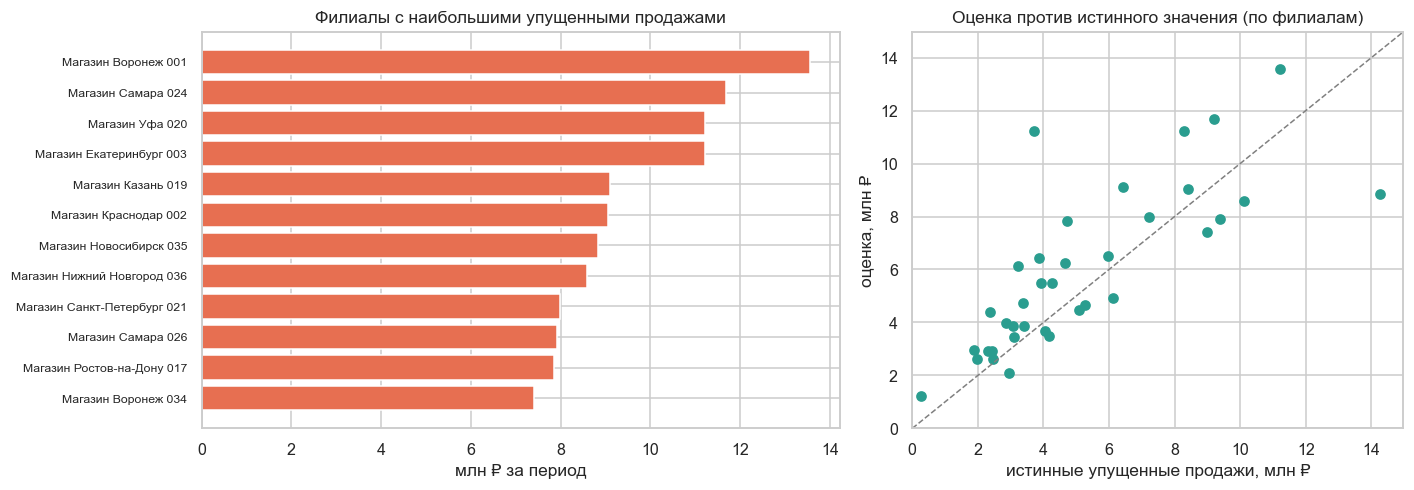

In [22]:
lost = stores.groupby('Филиал')[['упущено_руб', 'упущено_истинно_руб', 'Продажи_руб']].sum()
lost['доля'] = lost['упущено_руб'] / lost['Продажи_руб']
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={'width_ratios': [1.3, 1]})
top = lost.sort_values('упущено_руб', ascending=False).head(12)
axes[0].barh(top.index, top['упущено_руб'] / 1e6, color='#e76f51')
axes[0].invert_yaxis(); axes[0].tick_params(axis='y', labelsize=8)
axes[0].set(title='Филиалы с наибольшими упущенными продажами', xlabel='млн ₽ за период')
axes[1].scatter(lost['упущено_истинно_руб'] / 1e6, lost['упущено_руб'] / 1e6, color='#2a9d8f')
lim = max(lost['упущено_истинно_руб'].max(), lost['упущено_руб'].max()) / 1e6 * 1.05
axes[1].plot([0, lim], [0, lim], color='grey', ls='--', lw=1)
axes[1].set(title='Оценка против истинного значения (по филиалам)', xlabel='истинные упущенные продажи, млн ₽',
            ylabel='оценка, млн ₽', xlim=(0, lim), ylim=(0, lim))
plt.tight_layout(); plt.show()

## Сохранение результатов

Агрегаты для графиков записываются в схему `results` базы - из них собираются данные для страницы проекта
на сайте.

In [23]:
def save(frame: pd.DataFrame, table: str):
    con.execute('CREATE SCHEMA IF NOT EXISTS results')
    con.register('tmp_df', frame)
    con.execute(f'CREATE OR REPLACE TABLE results.{table} AS SELECT * FROM tmp_df')
    con.unregister('tmp_df')


save(avail.stack().rename('share').reset_index().rename(columns={'Филиал': 'branch', 'datetime': 'date'}), 'stock_availability')
save(net.rename(columns={'datetime': 'date', 'Линейка': 'line', 'Остатки_шт': 'stock', 'Продажи_шт': 'sales'}), 'stock_lines')
save(by_sku.rename(columns={'Товар': 'sku', 'Ассортиментный_Статус': 'status', 'доля дней дефицита': 'deficit_share'}),
     'stock_sku_deficit')
save(lost.reset_index().rename(columns={'Филиал': 'branch', 'упущено_руб': 'lost_est', 'упущено_истинно_руб': 'lost_true',
                                        'Продажи_руб': 'sales', 'доля': 'lost_share'}), 'stock_lost_by_branch')
summary = pd.DataFrame([
    ('period_from', START_DATE.strftime('%Y-%m-%d')), ('period_to', END_DATE.strftime('%Y-%m-%d')),
    ('rows', len(check)), ('match_share', float((diff == 0).mean())), ('max_abs_diff', float(diff.abs().max())),
    ('availability', float(1 - stores['Дефицит'].mean())), ('sales_rub', float(total_sales)),
    ('lost_est_rub', float(est)), ('lost_true_rub', float(true)),
    ('branches', int(stores['Филиал'].nunique())), ('skus', int(stores['Товар'].nunique())),
], columns=['metric', 'value'])
summary['value'] = summary['value'].astype(str)
save(summary, 'stock_summary')
con.close()

## Отличия от первоначальной портфолио-версии

- **Реальные SQL-запросы** к базе вместо сокращённых описаний; структура таблиц - как у выгрузок 1С.
- **Исправлен фильтр в конце восстановления**: дни с нулевым остатком больше не отбрасываются.
- **Добавлены проверка на истинном остатке, анализ наличия и оценка упущенных продаж** - раньше ноутбук
  заканчивался итоговой таблицей.